# SIREN 라벨 분석
dataset_index.csv 기반 표면처리 도메인 분석

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)

CSV_PATH = Path.home() / 'Desktop/Final_PJ/siren-api/vision/data/dataset_index.csv'
OUTPUT_DIR = Path.home() / 'Desktop/Final_PJ/siren-api/vision/data'

df = pd.read_csv(CSV_PATH)
print(f'총 row 수: {len(df):,}')
df.head()

총 row 수: 299,123


,file_name,split,domain,defect_name,part_name,category_id,label_type,width,height,date_captured,area,zip_source
0,2102_12_18abe76f-9272-4b9b-bb64-435c3d8337f0.JPG,TL,표면처리,균열,도장,2102,segmentation+bbox,3024,4032,2023-09-19 15:37:23,491417.3,TL_표면처리_균열_도장.zip
1,2102_12_0453f25b-076d-4c2d-8839-223ba37f6abf.JPG,TL,표면처리,균열,도장,2102,segmentation+bbox,3248,2432,2023-09-07 16:58:44,194051.5,TL_표면처리_균열_도장.zip
2,2102_12_0453f25b-076d-4c2d-8839-223ba37f6abf.JPG,TL,표면처리,균열,도장,2102,segmentation+bbox,3248,2432,2023-09-07 16:58:44,291465.5,TL_표면처리_균열_도장.zip
3,2102_12_0453f25b-076d-4c2d-8839-223ba37f6abf.JPG,TL,표면처리,균열,도장,2102,segmentation+bbox,3248,2432,2023-09-07 16:58:44,117738.4,TL_표면처리_균열_도장.zip
4,2102_12_a56ff778-8924-407c-8197-a41c633d3b1d.jpg,TL,표면처리,균열,도장,2102,segmentation+bbox,2992,2992,2023-09-19 10:06:04,413034.6,TL_표면처리_균열_도장.zip


## 1. 기본 현황

In [25]:
print('=== 컬럼 타입 ===')
print(df.dtypes)
print()
print('=== 결측치 ===')
print(df.isnull().sum())
print()
print('=== TL / VL 비율 ===')
print(df['split'].value_counts())
print()
print('=== 도메인 분포 ===')
print(df['domain'].value_counts())

=== 컬럼 타입 ===
file_name            str
split                str
domain               str
defect_name          str
part_name            str
category_id        int64
label_type           str
width              int64
height             int64
date_captured        str
area             float64
zip_source           str
dtype: object

=== 결측치 ===
file_name            0
split                0
domain               0
defect_name          0
part_name            0
category_id          0
label_type           0
width                0
height               0
date_captured        0
area             88451
zip_source           0
dtype: int64

=== TL / VL 비율 ===
split
TL    265834
VL     33289
Name: count, dtype: int64

=== 도메인 분포 ===
domain
표면처리     183344
케이블       31733
절단        28660
용접        22268
폼스프레이     17644
파이프       15474
Name: count, dtype: int64


## 2. 클래스별 샘플 수

In [26]:
defect_counts = df.groupby(['defect_name', 'split']).size().unstack(fill_value=0)
print(defect_counts)
print()
print(f'총 클래스 수: {len(defect_counts)}')

split           TL    VL
defect_name             
균열           25185  3071
도막떨어짐        11107  1335
도막분리          9523  1200
도장흐름         10381  1272
바인딩불량         9870  1220
바인딩양품         2104   255
보온재손상         9750  1232
볼트체결불량        8992  1110
볼트체결양품        4770   602
스크래치         34139  4342
용접불량          5386   668
용접블로우홀        8948  1066
용접양품          5500   700
절단불량         17842  2303
절단양품          7533   982
케이블설치불량       4135   505
케이블설치양품       4068   560
케이블손상         5293   658
케이블양품         2685   380
탱크클리닝불량      18443  2305
폼스프레이불량      11011  1377
폼스프레이양품       4672   584
표면양품         44497  5562

총 클래스 수: 23


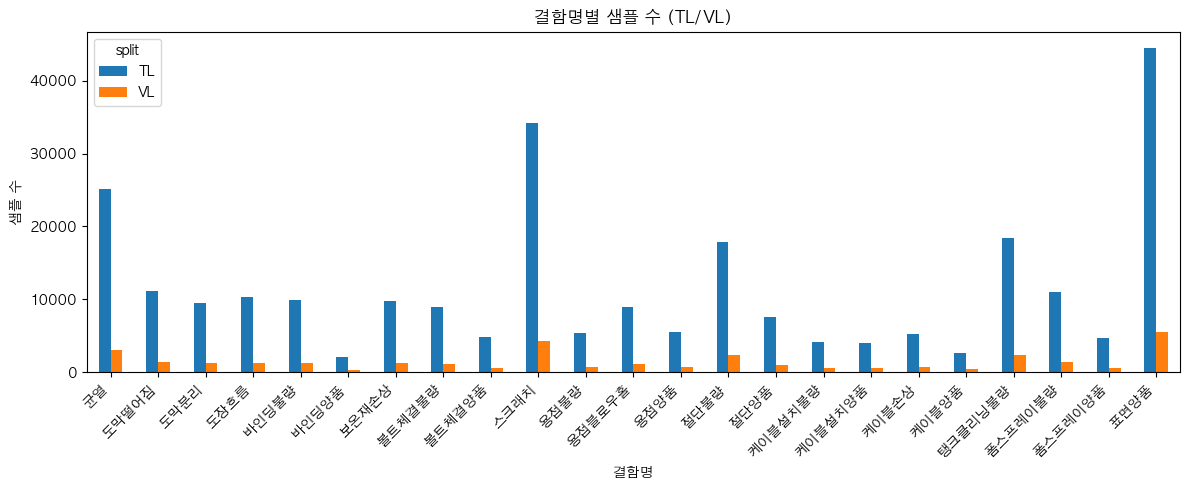

In [27]:
defect_counts.plot(kind='bar', figsize=(12, 5))
plt.title('결함명별 샘플 수 (TL/VL)')
plt.xlabel('결함명')
plt.ylabel('샘플 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'defect_counts.png', dpi=150)
plt.show()

## 3. 양품 vs 불량 비율

In [28]:
# category_id 끝자리 1=양품, 2=불량
df['is_defect'] = df['category_id'].apply(lambda x: x % 10 == 2)

ratio = df['is_defect'].value_counts()
ratio.index = ['불량', '양품']
print('=== 전체 기준 ===')
print(ratio)
print()

# TL / VL 각각
for split in ['TL', 'VL']:
    sub = df[df['split'] == split]['is_defect'].value_counts(normalize=True)
    print(f'=== {split} 기준 ===')
    print(f'  불량: {sub.get(True, 0)*100:.1f}%')
    print(f'  양품: {sub.get(False, 0)*100:.1f}%')

=== 전체 기준 ===
불량    213669
양품     85454
Name: count, dtype: int64

=== TL 기준 ===
  불량: 71.5%
  양품: 28.5%
=== VL 기준 ===
  불량: 71.1%
  양품: 28.9%


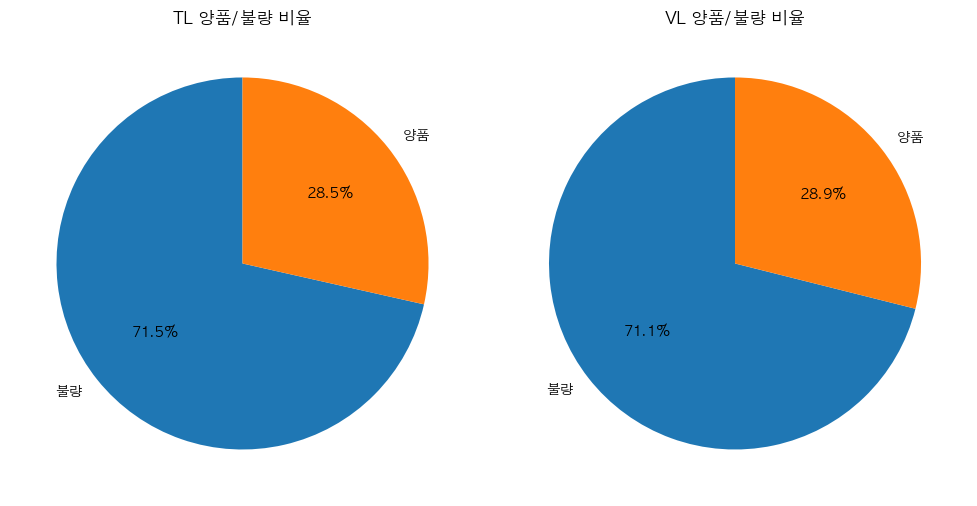

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, split in zip(axes, ['TL', 'VL']):
    sub = df[df['split'] == split]['is_defect'].value_counts()
    sub.index = ['불량', '양품']
    ax.pie(sub, labels=sub.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{split} 양품/불량 비율')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'defect_ratio.png', dpi=150)
plt.show()

## 4. part_name × defect_name 조합 (RAG 매뉴얼 작성 범위)

In [30]:
combo = (
    df.groupby(['defect_name', 'part_name'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
print(f'총 조합 수: {len(combo)}개  ← 매뉴얼 작성 필요 문서 수')
print()
print(combo.to_string(index=False))
combo.to_csv(OUTPUT_DIR / 'combo_counts.csv', index=False)

총 조합 수: 43개  ← 매뉴얼 작성 필요 문서 수

defect_name part_name  count
    탱크클리닝불량        모재  20748
       표면양품        모재  20029
       표면양품       보온재  17121
         균열        도장  14859
       스크래치       보온재  13427
       스크래치        도장  13421
         균열       보온재  13397
       표면양품        도장  12909
    폼스프레이불량      우레탄폼  12388
      도막떨어짐        도장  11952
       도장흐름        도장  11653
      바인딩불량     케이블타이  11090
      보온재손상       보온재  10982
       스크래치        모재  10911
       도막분리        도장  10721
       절단불량       보온재  10644
     볼트체결불량       파이프  10097
     용접블로우홀       조인트  10014
       절단불량        모재   9501
       용접양품       조인트   6198
       용접불량       조인트   6053
      케이블손상       케이블   5937
     볼트체결양품       파이프   5275
       절단양품       보온재   5269
    폼스프레이양품      우레탄폼   5256
    케이블설치불량    케이블그랜드   4640
    케이블설치양품    케이블그랜드   4628
       절단양품        모재   3246
      케이블양품       케이블   3065
      바인딩양품     케이블타이   2359
       스크래치       조인트    706
      도막떨어짐     케이블타이    468
     볼트체결양품 

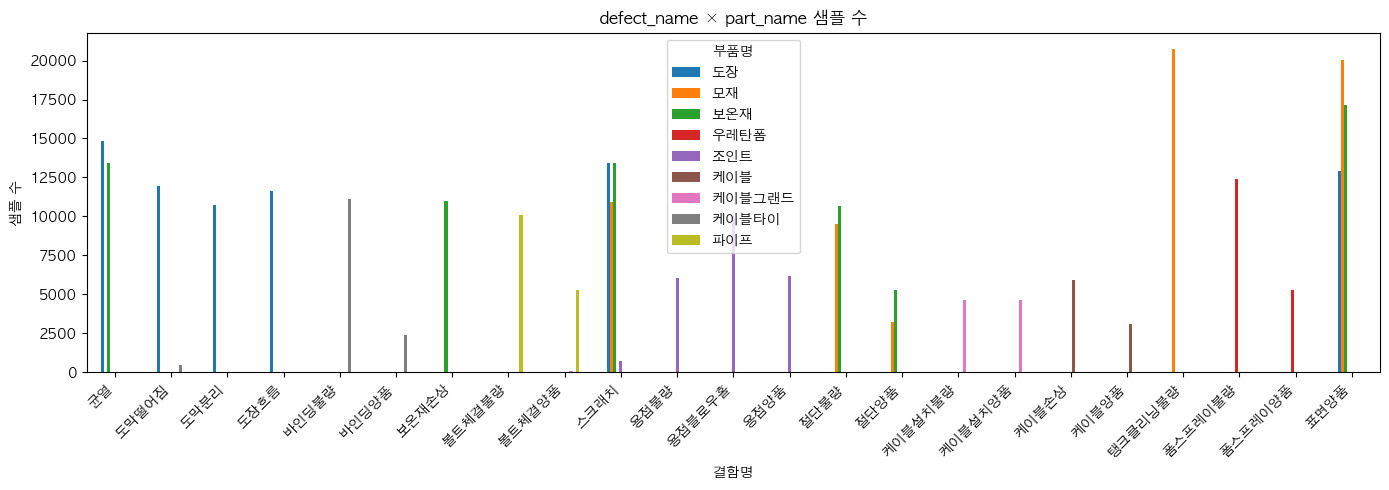

In [31]:
combo_pivot = combo.pivot(index='defect_name', columns='part_name', values='count').fillna(0)
combo_pivot.plot(kind='bar', figsize=(14, 5))
plt.title('defect_name × part_name 샘플 수')
plt.xlabel('결함명')
plt.ylabel('샘플 수')
plt.xticks(rotation=45, ha='right')
plt.legend(title='부품명')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'combo_counts.png', dpi=150)
plt.show()

## 5. 라벨 타입 분포 (시각화 전략 확정)

split                  TL     VL
label_type                      
bbox                21965   2777
classification      78623   9828
segmentation+bbox  165246  20684


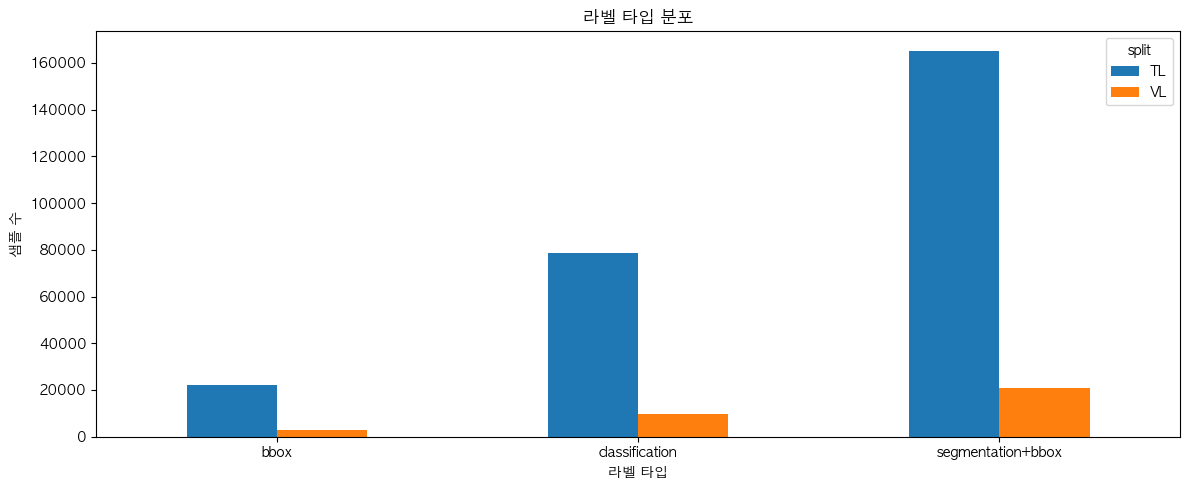

In [32]:
label_type = df.groupby(['label_type', 'split']).size().unstack(fill_value=0)
print(label_type)

label_type.plot(kind='bar')
plt.title('라벨 타입 분포')
plt.xlabel('라벨 타입')
plt.ylabel('샘플 수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'label_type.png', dpi=150)
plt.show()

## 6. 해상도 확인 (YOLOv8 입력 사이즈)

In [33]:
resolutions = df.groupby(['width', 'height']).size().reset_index(name='count')
print('=== 해상도 분포 ===')
print(resolutions.sort_values('count', ascending=False))

=== 해상도 분포 ===
      width  height  count
1152   3024    4032  83909
736    2992    2992  60237
746    3000    4000  41545
1297   3248    2432  31644
298    2432    3248  20398
...     ...     ...    ...
672    2927    4027      1
671    2925    3723      1
669    2922    4032      1
668    2921    3862      1
940    3024    3487      1

[1881 rows x 3 columns]


## 7. 데이터 품질 — 이상값 확인

In [34]:
# area 이상값
df['area'] = pd.to_numeric(df['area'], errors='coerce')
zero_area = df[df['area'] <= 0]
print(f'area=0 이하: {len(zero_area)}개')

# 유효하지 않은 category_id
VALID_IDS = {
    1101, 1102, 1202,
    2101, 2102, 2202, 2302, 2402, 2502, 2602, 2702,
    3101, 3102,
    4101, 4102, 4201, 4202, 4301, 4302,
    5101, 5102,
    6101, 6102,
}
invalid_ids = df[~df['category_id'].isin(VALID_IDS)]
print(f'유효하지 않은 category_id: {len(invalid_ids)}개')
if len(invalid_ids) > 0:
    print(invalid_ids['category_id'].value_counts())

print()
print('=== 품질 요약 ===')
print(f'전체 row:              {len(df):,}개')
print(f'area 이상값:           {len(zero_area)}개')
print(f'유효하지 않은 category: {len(invalid_ids)}개')

area=0 이하: 0개
유효하지 않은 category_id: 0개

=== 품질 요약 ===
전체 row:              299,123개
area 이상값:           0개
유효하지 않은 category: 0개


## 8. 촬영 기간 분포

=== 월별 촬영 분포 ===
year_month
2023-05        41
2023-07      7965
2023-08    123222
2023-09     76887
2023-10     91008
Freq: M, dtype: int64


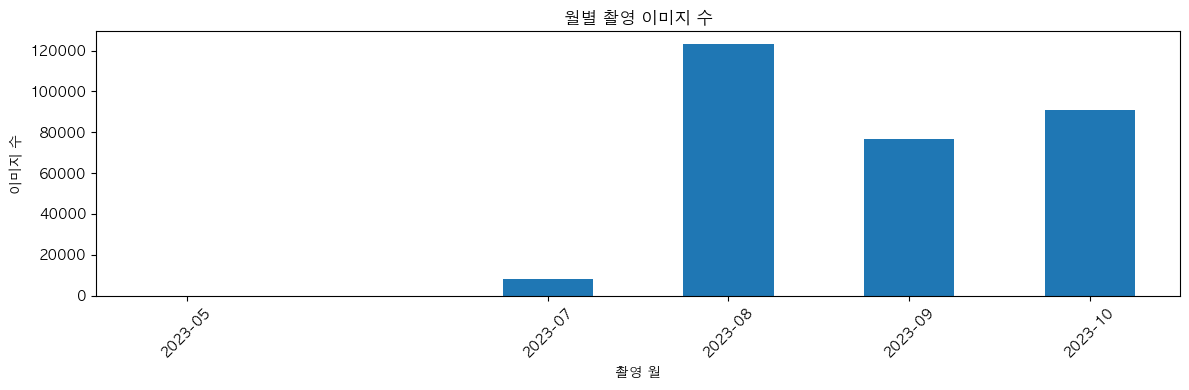

In [35]:
df['date_captured'] = pd.to_datetime(df['date_captured'], errors='coerce')
df['year_month'] = df['date_captured'].dt.to_period('M')

date_dist = df.groupby('year_month').size()
print('=== 월별 촬영 분포 ===')
print(date_dist)

date_dist.plot(kind='bar', figsize=(12, 4))
plt.title('월별 촬영 이미지 수')
plt.xlabel('촬영 월')
plt.ylabel('이미지 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'date_distribution.png', dpi=150)
plt.show()

## 9. 분석 요약

In [36]:
print('=' * 50)
print('SIREN 표면처리 라벨 분석 요약')
print('=' * 50)
print(f'총 이미지 수:      {len(df):,}개')
print(f'TL:                {len(df[df["split"]=="TL"]):,}개')
print(f'VL:                {len(df[df["split"]=="VL"]):,}개')
print(f'결함 클래스 수:    {df["defect_name"].nunique()}개')
print(f'부품 종류:         {df["part_name"].nunique()}개')
print(f'RAG 매뉴얼 범위:   {len(combo)}개 조합')
print(f'라벨 타입:         {df["label_type"].unique()}')
print(f'해상도:            {df[["width","height"]].drop_duplicates().values}')
print()
print('불량 클래스별 최소 샘플 수:')
defect_only = df[df['is_defect'] == True]
min_samples = defect_only.groupby('defect_name').size().sort_values()
print(min_samples)
print()
print(f'→ 샘플링 기준 추천: {min_samples.min()}장 이하 클래스 주의')

SIREN 표면처리 라벨 분석 요약
총 이미지 수:      299,123개
TL:                265,834개
VL:                33,289개
결함 클래스 수:    23개
부품 종류:         9개
RAG 매뉴얼 범위:   43개 조합
라벨 타입:         <ArrowStringArray>
['segmentation+bbox', 'bbox', 'classification']
Length: 3, dtype: str
해상도:            [[3024 4032]
 [3248 2432]
 [2992 2992]
 ...
 [2585 4024]
 [2329 4032]
 [3015 3885]]

불량 클래스별 최소 샘플 수:
defect_name
케이블설치불량     4640
케이블손상       5951
용접불량        6054
용접블로우홀     10014
볼트체결불량     10102
도막분리       10723
보온재손상      10982
바인딩불량      11090
도장흐름       11653
폼스프레이불량    12388
도막떨어짐      12442
절단불량       20145
탱크클리닝불량    20748
균열         28256
스크래치       38481
dtype: int64

→ 샘플링 기준 추천: 4640장 이하 클래스 주의


In [37]:
# 1. 용접불량 1개 어디서 왔는지
df[df['defect_name'] == '용접불량'][['file_name', 'zip_source']]


,file_name,zip_source
2146,2102_12_24a0047d-4aba-488a-b173-cece8745f8c6.jpg,TL_표면처리_균열_도장.zip
13345,1102_14_00293542-da81-45f9-82fb-c8da57ac4d1e.jpg,TL_용접_용접불량_조인트.zip
13346,1102_14_001115f5-fb1d-484d-8cbd-1cdd4f66f31c.jpg,TL_용접_용접불량_조인트.zip
13347,1102_14_0045be07-b65e-4045-b69c-fad3e7f8ab49.jpg,TL_용접_용접불량_조인트.zip
13348,1102_14_00889eb6-cebf-401e-95d5-da3b9da1842b.jpg,TL_용접_용접불량_조인트.zip
...,...,...
266515,1102_14_3f213047-32db-4cca-a5a6-93608b0c3e1d.jpg,VL_용접_용접불량_조인트.zip
266516,1102_14_3e7178a3-b1e9-4526-8a75-47f3ca57a656.jpg,VL_용접_용접불량_조인트.zip
266517,1102_14_3fb982a9-110e-4564-abd9-cadd3469d6f3.jpg,VL_용접_용접불량_조인트.zip
266518,1102_14_3f0f519d-3797-4ed7-bb3f-6d1cea62d2c7.jpg,VL_용접_용접불량_조인트.zip


In [38]:

# 2. classification 타입 몇 개인지
df[df['label_type'] == 'classification'].shape


(88451, 14)

In [39]:
# 3. 해상도 분포 상세
df.groupby(['width', 'height']).size().sort_values(ascending=False).head(10)

width  height
3024   4032      83909
2992   2992      60237
3000   4000      41545
3248   2432      31644
2432   3248      20398
4000   3000      20198
4032   3024      14021
3024   3024      12865
4032   1816       7953
3072   4096       1319
dtype: int64

In [18]:
# 노트북에서 확인
df.groupby(['defect_name', 'label_type']).size().unstack(fill_value=0)

label_type,classification,segmentation+bbox
defect_name,,
균열,0,28255
도막떨어짐,0,11952
도막분리,0,10721
도장흐름,0,11653
보온재손상,0,10982
스크래치,0,37758
용접불량,0,1
용접양품,0,2
탱크클리닝불량,20748,0


=== 클래스별 샘플 수 (TL) ===
defect_name
용접불량           1
용접양품           2
도막분리        9521
보온재손상       9750
도장흐름       10381
도막떨어짐      10669
탱크클리닝불량    18443
균열         25184
스크래치       33504
표면양품       44497
dtype: int64

=== 500장 미만 클래스 ===
defect_name
용접불량    1
용접양품    2
dtype: int64


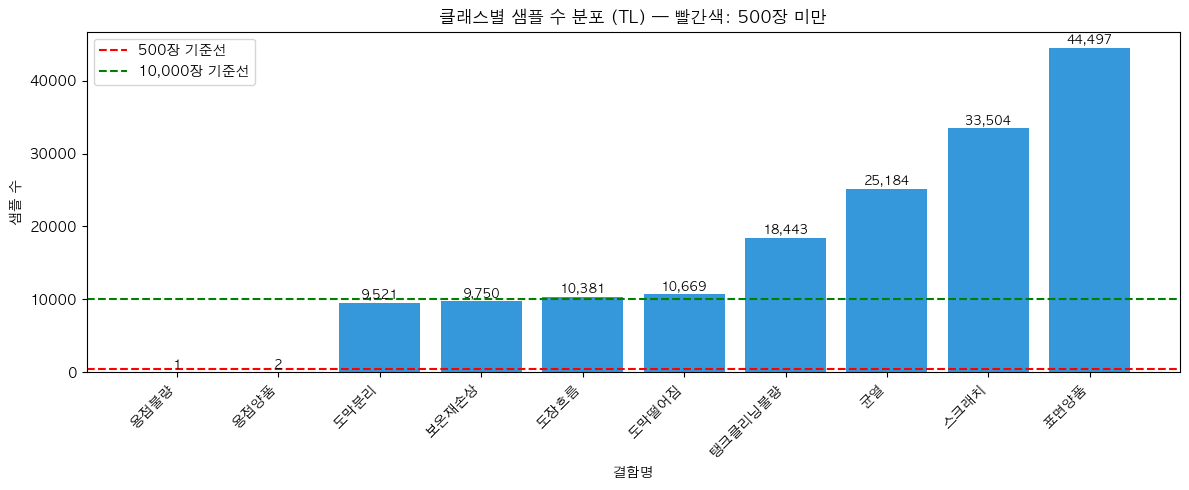


=== 샘플링 전략 ===
⚠️  500장 미만 클래스 존재
→ Stratified Sampling 적용
→ 500장 미만 클래스: 전체 사용
→ 500장 이상 클래스: 500장 랜덤 샘플링

확정 전략: stratified


In [19]:
# ── 투두리스트 실행 ────────────────────────────────────────
# 1. 전체 클래스별 파일 수 카운트
# 2. 500장 미만 클래스 식별
# 3. 불균형 시각화
# 4. 샘플링 전략 결정

# 1. 클래스별 파일 수 (TL 기준)
tl = df[df['split'] == 'TL']
class_counts = tl.groupby('defect_name').size().sort_values()
print('=== 클래스별 샘플 수 (TL) ===')
print(class_counts)

# 2. 500장 미만 클래스 식별
under_500 = class_counts[class_counts < 500]
print(f'\n=== 500장 미만 클래스 ===')
if len(under_500) == 0:
    print('없음 ✅')
else:
    print(under_500)

# 3. 시각화
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if v < 500 else '#3498db' for v in class_counts.values]
bars = ax.bar(class_counts.index, class_counts.values, color=colors)

ax.axhline(y=500, color='red', linestyle='--', linewidth=1.5, label='500장 기준선')
ax.axhline(y=10000, color='green', linestyle='--', linewidth=1.5, label='10,000장 기준선')

for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

ax.set_title('클래스별 샘플 수 분포 (TL) — 빨간색: 500장 미만')
ax.set_xlabel('결함명')
ax.set_ylabel('샘플 수')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150)
plt.show()

# 4. 샘플링 전략 결정
print('\n=== 샘플링 전략 ===')
if len(under_500) > 0:
    print('⚠️  500장 미만 클래스 존재')
    print('→ Stratified Sampling 적용')
    print('→ 500장 미만 클래스: 전체 사용')
    print('→ 500장 이상 클래스: 500장 랜덤 샘플링')
    SAMPLING_STRATEGY = 'stratified'
else:
    min_count = class_counts.min()
    print(f'✅ 모든 클래스 500장 이상')
    print(f'→ 최소 샘플 수: {min_count:,}장')
    print(f'→ 균등 샘플링: 클래스당 500장')
    SAMPLING_STRATEGY = 'uniform'

print(f'\n확정 전략: {SAMPLING_STRATEGY}')

In [20]:
# 용접 라벨 오류 제거 후 다시 체크
EXCLUDE_DEFECTS = ['용접불량', '용접양품', '용접블로우홀']
tl_clean = tl[~tl['defect_name'].isin(EXCLUDE_DEFECTS)]

class_counts = tl_clean.groupby('defect_name').size().sort_values()
under_500 = class_counts[class_counts < 500]

print('=== 클래스별 샘플 수 (오류 제거 후) ===')
print(class_counts)
print()

if len(under_500) == 0:
    print('✅ 모든 클래스 500장 이상')
    print(f'→ 최소 샘플 수: {class_counts.min():,}장')
    print('→ 확정 전략: uniform (클래스당 500장)')
    SAMPLING_STRATEGY = 'uniform'
else:
    print(f'⚠️  500장 미만: {under_500}')
    SAMPLING_STRATEGY = 'stratified'

print(f'\n확정 전략: {SAMPLING_STRATEGY}')

=== 클래스별 샘플 수 (오류 제거 후) ===
defect_name
도막분리        9521
보온재손상       9750
도장흐름       10381
도막떨어짐      10669
탱크클리닝불량    18443
균열         25184
스크래치       33504
표면양품       44497
dtype: int64

✅ 모든 클래스 500장 이상
→ 최소 샘플 수: 9,521장
→ 확정 전략: uniform (클래스당 500장)

확정 전략: uniform


# 전체 도베인 라벨타입 매핑 (sub-issue #20)

In [23]:
# ── 투두리스트: 전체 도메인 라벨타입 매핑 ──────────────────

import json

# df_clean 없으면 새로 정의
EXCLUDE_DEFECTS = ['용접불량', '용접양품', '용접블로우홀']
df_clean = df[~df['defect_name'].isin(EXCLUDE_DEFECTS)]

# 1. 표면처리 도메인 라벨타입 확인 (이슈 1 선행)
print('=== 표면처리 도메인 라벨타입 ===')
surface = df_clean[df_clean['domain'] == '표면처리']
surface_map = surface.groupby('defect_name')['label_type'].unique()
for defect, types in surface_map.items():
    print(f'  {defect}: {list(types)}')

# 2. 전체 도메인 라벨타입 매핑표 작성
print('\n=== 전체 도메인 라벨타입 매핑표 ===')
domain_label_map = {}

for domain in df['domain'].unique():
    domain_df = df[df['domain'] == domain]
    defect_map = {}

    for defect in domain_df['defect_name'].unique():
        defect_df = domain_df[domain_df['defect_name'] == defect]
        label_types = defect_df['label_type'].unique().tolist()
        defect_map[defect] = {
            'label_types': label_types,
            'sample_count': len(defect_df),
            'has_bbox': any('bbox' in lt for lt in label_types),
            'has_seg':  any('segmentation' in lt for lt in label_types),
            'is_cls':   any(lt == 'classification' for lt in label_types),
        }

    domain_label_map[domain] = defect_map
    print(f'\n  [{domain}]')
    for defect, info in defect_map.items():
        print(f'    {defect}: {info["label_types"]} ({info["sample_count"]:,}장)')

# 3. bbox/segmentation 혼재 도메인 식별
print('\n=== bbox/segmentation 혼재 도메인 ===')
mixed_domains = []
for domain, defects in domain_label_map.items():
    has_seg = any(v['has_seg']  for v in defects.values())
    has_cls = any(v['is_cls']   for v in defects.values())
    if has_seg and has_cls:
        mixed_domains.append(domain)
        print(f'  {domain}: segmentation+bbox + classification 혼재')

if not mixed_domains:
    print('  혼재 도메인 없음')

# json 저장 전에 용접 도메인 제거
domain_label_map.pop('용접', None)

with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(domain_label_map, f, ensure_ascii=False, indent=2)
print(f'✅ 저장 완료: {OUTPUT_PATH}')

# 4. domain_label_map.json 저장
OUTPUT_PATH = OUTPUT_DIR / 'domain_label_map.json'
with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(domain_label_map, f, ensure_ascii=False, indent=2)
print(f'\n✅ 저장 완료: {OUTPUT_PATH}')

# 5. 요약 테이블
print('\n=== 요약 ===')
print(f'{"도메인":<12} {"결함수":>6} {"seg+bbox":>10} {"cls":>6} {"혼재":>6}')
print('-' * 45)
for domain, defects in domain_label_map.items():
    n_defects = len(defects)
    n_seg     = sum(1 for v in defects.values() if v['has_seg'])
    n_cls     = sum(1 for v in defects.values() if v['is_cls'])
    mixed     = '⚠️' if n_seg > 0 and n_cls > 0 else '✅'
    print(f'{domain:<12} {n_defects:>6} {n_seg:>10} {n_cls:>6} {mixed:>6}')

=== 표면처리 도메인 라벨타입 ===
  균열: ['segmentation+bbox']
  도막떨어짐: ['segmentation+bbox']
  도막분리: ['segmentation+bbox']
  도장흐름: ['segmentation+bbox']
  보온재손상: ['segmentation+bbox']
  스크래치: ['segmentation+bbox']
  탱크클리닝불량: ['classification']
  표면양품: ['classification']

=== 전체 도메인 라벨타입 매핑표 ===

  [표면처리]
    균열: ['segmentation+bbox'] (28,255장)
    스크래치: ['segmentation+bbox'] (37,758장)
    도장흐름: ['segmentation+bbox'] (11,653장)
    도막떨어짐: ['segmentation+bbox'] (11,952장)
    도막분리: ['segmentation+bbox'] (10,721장)
    보온재손상: ['segmentation+bbox'] (10,982장)
    탱크클리닝불량: ['classification'] (20,748장)
    표면양품: ['classification'] (50,059장)

  [용접]
    용접불량: ['segmentation+bbox'] (1장)
    용접양품: ['segmentation+bbox'] (2장)

=== bbox/segmentation 혼재 도메인 ===
  표면처리: segmentation+bbox + classification 혼재
✅ 저장 완료: /Users/seolhakim/Desktop/Final_PJ/siren-api/vision/data/domain_label_map.json

✅ 저장 완료: /Users/seolhakim/Desktop/Final_PJ/siren-api/vision/data/domain_label_map.json

=== 요약 ===
도메인             결함수   se

In [43]:
# 전체 도메인 기준으로 df_clean 재정의
df = pd.read_csv(CSV_PATH)

EXCLUDE_DEFECTS = ['용접불량', '용접양품', '용접블로우홀']
df_clean = df[~df['defect_name'].isin(EXCLUDE_DEFECTS)]

print(f'전체: {len(df):,}개')
print(f'df_clean: {len(df_clean):,}개')
print(df_clean['domain'].value_counts())

VALID_COMBOS = {
    '용접':      ['조인트'],
    '절단':      ['모재', '보온재'],
    '케이블':    ['케이블타이', '케이블그랜드', '케이블'],
    '파이프':    ['파이프'],
    '폼스프레이': ['우레탄폼'],
    '표면처리':  ['도장', '모재', '보온재'],
}

df_valid = df_clean[
    df_clean.apply(
        lambda r: r['part_name'] in VALID_COMBOS.get(r['domain'], []),
        axis=1
    )
]
print(f'오류 제거 전: {len(df_clean):,}개')
print(f'오류 제거 후: {len(df_valid):,}개')
print(f'제거된 것:   {len(df_clean)-len(df_valid):,}개')

전체: 299,123개
df_clean: 276,855개
domain
표면처리     183344
케이블       31733
절단        28660
폼스프레이     17644
파이프       15474
Name: count, dtype: int64
오류 제거 전: 276,855개
오류 제거 후: 275,539개
제거된 것:   1,316개


In [44]:
# 정상 조합 수 재확인
valid_combo = (
    df_valid
    .groupby(['domain', 'defect_name', 'part_name'])
    .size()
    .reset_index(name='count')
    .sort_values(['domain', 'count'], ascending=[True, False])
)
print(f'정상 조합 수: {len(valid_combo)}개  ← RAG 매뉴얼 작성 범위')
print()
print(valid_combo.to_string(index=False))

정상 조합 수: 28개  ← RAG 매뉴얼 작성 범위

domain defect_name part_name  count
    절단        절단불량       보온재  10644
    절단        절단불량        모재   9501
    절단        절단양품       보온재   5269
    절단        절단양품        모재   3246
   케이블       바인딩불량     케이블타이  11090
   케이블       케이블손상       케이블   5937
   케이블     케이블설치불량    케이블그랜드   4640
   케이블     케이블설치양품    케이블그랜드   4628
   케이블       케이블양품       케이블   3065
   케이블       바인딩양품     케이블타이   2359
   케이블       케이블손상     케이블타이     14
   파이프      볼트체결불량       파이프  10097
   파이프      볼트체결양품       파이프   5275
 폼스프레이     폼스프레이불량      우레탄폼  12388
 폼스프레이     폼스프레이양품      우레탄폼   5256
  표면처리     탱크클리닝불량        모재  20748
  표면처리        표면양품        모재  20029
  표면처리        표면양품       보온재  17121
  표면처리          균열        도장  14859
  표면처리        스크래치       보온재  13427
  표면처리        스크래치        도장  13421
  표면처리          균열       보온재  13397
  표면처리        표면양품        도장  12909
  표면처리       도막떨어짐        도장  11952
  표면처리        도장흐름        도장  11653
  표면처리       보온재손상       보온재  109

In [45]:
# 이제부터 df_valid가 기준
# df_clean 대신 df_valid 사용
df_clean = df_valid.copy()
print(f'최종 데이터: {len(df_clean):,}개')
print(df_clean['domain'].value_counts())

최종 데이터: 275,539개
domain
표면처리     182130
케이블       31733
절단        28660
폼스프레이     17644
파이프       15372
Name: count, dtype: int64


In [46]:
# 케이블 오류 조합 제거
df_clean = df_clean[
    ~((df_clean['defect_name'] == '케이블손상') &
      (df_clean['part_name'] == '케이블타이'))
]
print(f'최종 데이터: {len(df_clean):,}개')
print(f'최종 조합 수: {df_clean.groupby(["defect_name","part_name"]).nunique().shape[0]}개')

최종 데이터: 275,525개
최종 조합 수: 27개


In [48]:
# ── 전수검사: domain-defect_name-part_name 매핑 이상치 탐지 ──

# 도메인별 허용 결함명
valid_defects = {
    '용접':      ['용접불량', '용접블로우홀', '용접양품'],
    '절단':      ['절단불량', '절단양품'],
    '케이블':    ['바인딩불량', '바인딩양품', '케이블설치불량',
                  '케이블설치양품', '케이블손상', '케이블양품'],
    '파이프':    ['볼트체결불량', '볼트체결양품'],
    '폼스프레이': ['폼스프레이불량', '폼스프레이양품'],
    '표면처리':  ['균열', '도막떨어짐', '도막분리', '도장흐름',
                  '보온재손상', '스크래치', '탱크클리닝불량', '표면양품'],
}

# 도메인별 허용 부품명
valid_parts = {
    '용접':      ['조인트'],
    '절단':      ['모재', '보온재'],
    '케이블':    ['케이블타이', '케이블그랜드', '케이블'],
    '파이프':    ['파이프'],
    '폼스프레이': ['우레탄폼'],
    '표면처리':  ['도장', '모재', '보온재'],
}

# 1. defect_name → domain 매핑 깨진 것
print('=' * 60)
print('1. defect_name → domain 매핑 이상치')
print('=' * 60)
defect_anomaly = df[
    ~df.apply(
        lambda x: x['defect_name'] in valid_defects.get(x['domain'], []),
        axis=1
    )
]
if len(defect_anomaly) == 0:
    print('✅ 이상치 없음')
else:
    print(f'⚠️  총 {len(defect_anomaly):,}개')
    print()
    summary = (
        defect_anomaly
        .groupby(['domain', 'defect_name', 'part_name'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )
    print(summary.to_string(index=False))

print()

# 2. part_name → domain 매핑 깨진 것
print('=' * 60)
print('2. part_name → domain 매핑 이상치')
print('=' * 60)
part_anomaly = df[
    ~df.apply(
        lambda x: x['part_name'] in valid_parts.get(x['domain'], []),
        axis=1
    )
]
if len(part_anomaly) == 0:
    print('✅ 이상치 없음')
else:
    print(f'⚠️  총 {len(part_anomaly):,}개')
    print()
    summary2 = (
        part_anomaly
        .groupby(['domain', 'defect_name', 'part_name'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )
    print(summary2.to_string(index=False))

print()

# 3. 두 조건 동시 만족하는 것 (완전 정상)
print('=' * 60)
print('3. 최종 정상 데이터 확인')
print('=' * 60)
df_final = df[
    df.apply(lambda x:
        x['defect_name'] in valid_defects.get(x['domain'], []) and
        x['part_name']   in valid_parts.get(x['domain'], []),
        axis=1
    )
]
print(f'전체:  {len(df):,}개')
print(f'정상:  {len(df_final):,}개')
print(f'제거:  {len(df) - len(df_final):,}개')
print()
print(df_final['domain'].value_counts())
print()
print(f'최종 조합 수: {df_final.groupby(["defect_name","part_name"]).ngroups}개')

1. defect_name → domain 매핑 이상치
✅ 이상치 없음

2. part_name → domain 매핑 이상치
⚠️  총 1,319개

domain defect_name part_name  count
  표면처리        스크래치       조인트    706
  표면처리       도막떨어짐     케이블타이    468
   파이프      볼트체결양품    케이블그랜드     97
  표면처리       도막떨어짐       케이블     17
  표면처리        스크래치     케이블타이     10
  표면처리        스크래치       케이블      6
   파이프      볼트체결불량    케이블그랜드      5
  표면처리       도막떨어짐       파이프      5
  표면처리        도막분리     케이블타이      2
    용접        용접불량        도장      1
    용접        용접양품        도장      1
    용접        용접양품       보온재      1

3. 최종 정상 데이터 확인
전체:  299,123개
정상:  297,804개
제거:  1,319개

domain
표면처리     182130
케이블       31733
절단        28660
용접        22265
폼스프레이     17644
파이프       15372
Name: count, dtype: int64

최종 조합 수: 31개


In [49]:
df_clean = df_final.copy()

print(f'최종 데이터: {len(df_clean):,}개')
print(f'최종 조합 수: {df_clean.groupby(["defect_name","part_name"]).ngroups}개')
print()
print(df_clean['domain'].value_counts())

최종 데이터: 297,804개
최종 조합 수: 31개

domain
표면처리     182130
케이블       31733
절단        28660
용접        22265
폼스프레이     17644
파이프       15372
Name: count, dtype: int64
